# Inférence statistique

> Modèles retenus : CatBoost, XGBoost, LightGBM (cible `log1p`) + Stacking OOF  
> Optimisation sur **MAPE** (au lieu de MAE) + feature engineering ciblé sur les petites valeurs.

## Imports & configuration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import cross_val_predict
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 1308
N_TRIALS     = 1

## Chargement des données

In [3]:
df_train = pd.read_csv("../data_finale/featuring/train_featured.csv")
df_val   = pd.read_csv("../data_finale/featuring/val_featured.csv")
df_test  = pd.read_csv("../data_finale/featuring/test_featured.csv")

colonne_cible  = "market_value_in_eur"
colonne_joueur = "player"
colonne_team   = "team"
colonne_nation = "nation"

df_train = df_train.dropna(subset=[colonne_cible])
df_val   = df_val.dropna(subset=[colonne_cible])
df_test  = df_test.dropna(subset=[colonne_cible])

## Feature engineering ciblé


In [4]:
# On crée une base d'historique propre et triée par temps
df_history = pd.concat([df_train, df_val, df_test], axis=0)
df_history = df_history.sort_values(["player", "season_year"])

# On calcule le shift sur cet historique de référence
df_history["log_prev_value"] = np.log1p(
    df_history.groupby("player")["market_value_in_eur"].shift(1)
)

# On filtre par année (le vrai split temporel)
df_train = df_history[df_history["season_year"].isin([2020, 2021, 2022])].copy()
df_val   = df_history[df_history["season_year"] == 2023].copy()
df_test  = df_history[df_history["season_year"] == 2024].copy()

C:\Users\LouisHarle\AppData\Local\Temp\ipykernel_25144\1289132112.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_history["log_prev_value"] = np.log1p(


In [5]:

# On liste toutes tes colonnes qui commencent par 'league_'
league_cols = [col for col in df_train.columns if col.startswith('league_')]

def extraire_nom_ligue(df):
    df_temp = df.copy()
    # Si le joueur a un '1' dans une colonne league, on extrait le nom, sinon 'Other'
    df_temp['league_name'] = df_temp[league_cols].idxmax(axis=1).where(df_temp[league_cols].max(axis=1) == 1, 'league_Other')
    return df_temp

# On crée des versions temporaires avec la colonne 'league_name'
df_train_temp = extraire_nom_ligue(df_train)


# Médianes apprises sur le train (Croisement Ligue × Position)

# log_prev_value par ligue et position
prev_pos_league = (
    df_train_temp
    .groupby(["league_name", "position"])["log_prev_value"]
    .median()
)

# Médiane par position simple (en secours)
prev_pos_backup = (
    df_train_temp
    .groupby("position")["log_prev_value"]
    .median()
)

prev_global = df_train_temp["log_prev_value"].median()



# Fonction d'imputation

def impute_features(df):
    # On génère la colonne temporaire pour mapper les données
    df_with_league = extraire_nom_ligue(df)
    
    # Sauvegarde de l'index d'origine pour la conversion en Série
    original_index = df_with_league.index


    mapped_prev_value = (
        df_with_league.set_index(["league_name", "position"])
        .index.map(prev_pos_league)
        .to_series(index=original_index)
    )
    df_with_league["log_prev_value"] = df_with_league["log_prev_value"].fillna(mapped_prev_value)


    df_with_league["log_prev_value"] = df_with_league["log_prev_value"].fillna(
        df_with_league["position"].map(prev_pos_backup)
    )


    df_with_league["log_prev_value"] = df_with_league["log_prev_value"].fillna(
        prev_global
    )


    # On supprime la colonne temporaire avant de renvoyer le DataFrame propre
    return df_with_league.drop(columns=['league_name'])




df_train = impute_features(df_train)
df_val   = impute_features(df_val)
df_test  = impute_features(df_test)

## Préparation des jeux X / y

In [6]:
cols_a_supprimer = [
    colonne_cible, colonne_joueur, colonne_team, colonne_nation,
    "position"
]
# On supprime uniquement les colonnes qui existent réellement
cols_a_supprimer = [c for c in cols_a_supprimer if c in df_train.columns]

# La normalisation est inutile pour les modèles d'arbres, donc on supprime les colonnes normalisées
colonnes_nor = [c for c in df_train.columns if c.endswith("_nor")]

df_train = df_train.drop(columns=colonnes_nor, errors="ignore")
df_val   = df_val.drop(columns=colonnes_nor, errors="ignore")
df_test  = df_test.drop(columns=colonnes_nor, errors="ignore")

X_train = df_train.drop(columns=cols_a_supprimer)
y_train = df_train[colonne_cible]

X_val   = df_val.drop(columns=cols_a_supprimer)
y_val   = df_val[colonne_cible]

X_test  = df_test.drop(columns=cols_a_supprimer)
y_test  = df_test[colonne_cible]

# Cibles log
y_train_log = np.log1p(y_train)
y_val_log   = np.log1p(y_val)
y_test_log  = np.log1p(y_test)

# Poids d'entraînement : sur-pondère les petites valeurs pour améliorer le MAPE
sample_weights_train = 1 / np.log1p(y_train)
sample_weights_train = sample_weights_train / sample_weights_train.mean()

print(f"X_train : {X_train.shape} | X_val : {X_val.shape} | X_test : {X_test.shape}")

X_train : (7404, 144) | X_val : (2431, 144) | X_test : (1751, 144)


## Tuning Optuna — optimisation sur MAPE

On optimise directement le **MAPE** (erreur relative en %) plutôt que le MAE (erreur absolue en €).  
En effet, le MAE pousse le modèle à bien prédire les grosses valeurs (qui pèsent plus en €), au détriment du MAPE sur les petites valeurs (< 5M€) qui représentent 47% du dataset.

In [7]:
def objective_xgb(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 500, 5000, step=250),
        "max_depth":         trial.suggest_int("max_depth", 3, 12),
        "learning_rate":     trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight":  trial.suggest_float("min_child_weight", 0.5, 10),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
        "tree_method":       "hist",
        "enable_categorical": True,
        "objective":         "reg:squarederror",
        "random_state":      RANDOM_STATE,
        "n_jobs":            -1,
        "verbosity":         0,
    }
    
    model = XGBRegressor(**params)
    
    # Entraînement classique sur la cible log
    model.fit(X_train, y_train_log, sample_weight=sample_weights_train)
    
    # On fait la prédiction en log
    preds_log = model.predict(X_val)
    
    # On calcule le RMSE directement sur les logs (y_val_log) pour la stabilité d'Optuna
    return np.sqrt(mean_squared_error(y_val_log, preds_log))

print("--- Tuning XGBoost ---")
study_xgb = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_xgb.optimize(objective_xgb, n_trials=N_TRIALS, show_progress_bar=True)

best_model = XGBRegressor(**study_xgb.best_params, tree_method="hist", enable_categorical=True, random_state=RANDOM_STATE)
best_model.fit(X_train, y_train_log, sample_weight=sample_weights_train)
final_preds = np.expm1(best_model.predict(X_val))
final_mape = mean_absolute_percentage_error(y_val, final_preds)

print(f"Meilleur RMSE log val : {study_xgb.best_value:.4f}")
print(f"MAPE réel correspondant : {final_mape:.4f}")
print(f"Params : {study_xgb.best_params}")

--- Tuning XGBoost ---


Best trial: 0. Best value: 0.533733: 100%|██████████| 1/1 [00:24<00:00, 24.97s/it]


Meilleur RMSE log val : 0.5337
MAPE réel correspondant : 0.4234
Params : {'n_estimators': 1250, 'max_depth': 10, 'learning_rate': 0.006318598359104425, 'subsample': 0.5446062880266449, 'colsample_bytree': 0.9627983128285522, 'min_child_weight': 5.228175246239128, 'reg_alpha': 0.09344935130368964, 'reg_lambda': 0.15195575794699617}


In [8]:
def objective_lgbm(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 500, 5000, step=250),
        "num_leaves":        trial.suggest_int("num_leaves", 15, 255),
        "max_depth":         trial.suggest_int("max_depth", 3, 15),
        "learning_rate":     trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
        "random_state":      RANDOM_STATE,
        "n_jobs":            -1,
        "verbose":           -1,
    }
    model = LGBMRegressor(**params)
    model.fit(X_train, y_train_log, sample_weight=sample_weights_train)
    
    # On reste en log pour la prédiction
    preds_log = model.predict(X_val)
    
    # On renvoie le RMSE calculé sur les logs
    return np.sqrt(mean_squared_error(y_val_log, preds_log))

# Nettoyage des textes des prints pour l'affichage
print("--- Tuning LightGBM ---")
study_lgbm = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_lgbm.optimize(objective_lgbm, n_trials=N_TRIALS, show_progress_bar=True)

# Calcul du vrai MAPE global de fin hors de la boucle pour ton suivi business
best_lgbm = LGBMRegressor(**study_lgbm.best_params, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
best_lgbm.fit(X_train, y_train_log, sample_weight=sample_weights_train)
final_preds_lgbm = np.expm1(best_lgbm.predict(X_val))
final_mape_lgbm = mean_absolute_percentage_error(y_val, final_preds_lgbm)

print(f"Meilleur RMSE log val : {study_lgbm.best_value:.4f}")
print(f"MAPE réel correspondant : {final_mape_lgbm:.4f}")
print(f"Params : {study_lgbm.best_params}")

--- Tuning LightGBM ---


Best trial: 0. Best value: 0.569534: 100%|██████████| 1/1 [00:01<00:00,  1.32s/it]


Meilleur RMSE log val : 0.5695
MAPE réel correspondant : 0.4560
Params : {'n_estimators': 1250, 'num_leaves': 206, 'max_depth': 3, 'learning_rate': 0.006948545459606252, 'subsample': 0.9627983128285522, 'colsample_bytree': 0.7488513287494278, 'reg_alpha': 0.09344935130368964, 'reg_lambda': 0.15195575794699617}


In [9]:
def objective_catboost(trial):
    params = {
        "iterations":             trial.suggest_int("iterations", 500, 3000, step=500),
        "depth":                  trial.suggest_int("depth", 4, 8),
        "learning_rate":          trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "l2_leaf_reg":           trial.suggest_float("l2_leaf_reg", 1, 10),
        "subsample":              trial.suggest_float("subsample", 0.5, 1.0),
        "bootstrap_type":        "Bernoulli",
        "random_state":           RANDOM_STATE,
        "early_stopping_rounds": 50,
        "verbose":               0,
    }
    model = CatBoostRegressor(**params)
    model.fit(
        X_train, y_train_log,
        eval_set=(X_val, y_val_log),
        sample_weight=sample_weights_train,
        verbose=False
    )
    
    # On reste sur l'échelle des logs pour la prédiction
    preds_log = model.predict(X_val)
    
    # On calcule et renvoie le RMSE directement sur les logs (y_val_log)
    return np.sqrt(mean_squared_error(y_val_log, preds_log))

# Nettoyage des textes et des prints pour l'affichage
print("--- Tuning CatBoost ---")
study_cat = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_cat.optimize(objective_catboost, n_trials=N_TRIALS, show_progress_bar=True)

# Calcul du vrai MAPE global de fin hors de la boucle pour ton suivi business
best_cat = CatBoostRegressor(**study_cat.best_params, bootstrap_type="Bernoulli", random_state=RANDOM_STATE, verbose=0)
best_cat.fit(X_train, y_train_log, sample_weight=sample_weights_train, verbose=False)
final_preds_cat = np.expm1(best_cat.predict(X_val))
final_mape_cat = mean_absolute_percentage_error(y_val, final_preds_cat)

print(f"Meilleur RMSE log val : {study_cat.best_value:.4f}")
print(f"MAPE réel correspondant : {final_mape_cat:.4f}")
print(f"Params : {study_cat.best_params}")

--- Tuning CatBoost ---


Best trial: 0. Best value: 0.549468: 100%|██████████| 1/1 [00:13<00:00, 13.47s/it]


Meilleur RMSE log val : 0.5495
MAPE réel correspondant : 0.4387
Params : {'iterations': 1000, 'depth': 7, 'learning_rate': 0.011573108499339681, 'l2_leaf_reg': 1.8029131844796091, 'subsample': 0.9627983128285522}


## Modèles finaux & évaluation validation

In [10]:
xgb_final = XGBRegressor(
    **study_xgb.best_params,
    tree_method="hist", enable_categorical=True,
    objective="reg:squarederror",
    random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
)
lgbm_final = LGBMRegressor(
    **study_lgbm.best_params,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
)
cat_final = CatBoostRegressor(
    **study_cat.best_params,
    bootstrap_type="Bernoulli",
    random_state=RANDOM_STATE, early_stopping_rounds=50, verbose=0
)

modeles_finaux = {
    "XGBoost":   xgb_final,
    "LightGBM":  lgbm_final,
    "CatBoost":  cat_final,
}

def evaluer_log(nom, modele, X_tr, y_tr_log, X_ev, y_ev, w=None):
    fit_kwargs = {"sample_weight": w} if w is not None else {}
    if isinstance(modele, CatBoostRegressor):
        modele.fit(X_tr, y_tr_log, eval_set=(X_ev, np.log1p(y_ev)), verbose=False, **fit_kwargs)
    else:
        modele.fit(X_tr, y_tr_log, **fit_kwargs)
    preds = np.expm1(modele.predict(X_ev))
    mae   = mean_absolute_error(y_ev, preds)
    rmse  = np.sqrt(mean_squared_error(y_ev, preds))
    mape  = mean_absolute_percentage_error(y_ev, preds)
    r2    = r2_score(y_ev, preds)
    n, p  = len(y_ev), X_ev.shape[1]
    r2_adj = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    print(f"  {nom:12s} | MAPE : {mape:.2%} | MAE : {mae:>12,.0f} € | R² : {r2:.4f} | R²adj : {r2_adj:.4f}")
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape, "R2": r2, "R2 Ajusté": r2_adj}

print("Évaluation validation")
resultats_val = {}
for nom, modele in modeles_finaux.items():
    resultats_val[nom] = evaluer_log(nom, modele, X_train, y_train_log, X_val, y_val, w=sample_weights_train)

df_val_res = pd.DataFrame(resultats_val).T.sort_values("MAPE")
print("\nClassement validation (MAPE croissant) :")
print(df_val_res)

Évaluation validation
  XGBoost      | MAPE : 42.34% | MAE :    3,020,716 € | R² : 0.8881 | R²adj : 0.8811
  LightGBM     | MAPE : 45.60% | MAE :    3,483,550 € | R² : 0.8289 | R²adj : 0.8182
  CatBoost     | MAPE : 43.87% | MAE :    3,368,693 € | R² : 0.8546 | R²adj : 0.8454

Classement validation (MAPE croissant) :
                   MAE          RMSE      MAPE        R2  R2 Ajusté
XGBoost   3.020716e+06  6.019237e+06  0.423389  0.888137   0.881091
CatBoost  3.368693e+06  6.862622e+06  0.438739  0.854594   0.845434
LightGBM  3.483550e+06  7.443460e+06  0.455976  0.828939   0.818163


## Stacking OOF (Out-Of-Fold)

Le méta-modèle apprend le meilleur poids à donner à chaque modèle de base à partir de prédictions **hors-échantillon** (OOF), générées par cross-validation sur le train.  
Cela évite la fuite de données du stacking naïf sur la validation.

Le méta-modèle est entraîné sur les prédictions OOF **en espace log** pour que les poids restent stables, puis les prédictions finales sont retransformées avec `expm1`.

In [11]:
base_models = ["XGBoost", "LightGBM", "CatBoost"]

# OOF sur le train (cv=5)
print("Génération OOF predictions (cv=5)...")
oof_log = {}
for nom in base_models:
    modele = modeles_finaux[nom]
    oof    = cross_val_predict(modele, X_train, y_train_log, cv=5, n_jobs=-1)
    oof_log[nom] = oof
    print(f"  {nom:12s} | OOF MAE : {mean_absolute_error(y_train, np.expm1(oof)):>12,.0f} € | OOF MAPE : {mean_absolute_percentage_error(y_train, np.expm1(oof)):.2%}")

X_meta_train = pd.DataFrame(oof_log)

# Prédictions val & test (modèles ré-entraînés sur tout le train)
print("\nEntraînement final sur train complet...")
for nom in base_models:
    modele = modeles_finaux[nom]
    if isinstance(modele, CatBoostRegressor):
        modele.fit(X_train, y_train_log, eval_set=(X_val, y_val_log),
                   sample_weight=sample_weights_train, verbose=False)
    else:
        modele.fit(X_train, y_train_log, sample_weight=sample_weights_train)
    print(f"  {nom} : entraîné")

preds_val_log  = {nom: modeles_finaux[nom].predict(X_val)  for nom in base_models}
preds_test_log = {nom: modeles_finaux[nom].predict(X_test) for nom in base_models}

X_meta_val  = pd.DataFrame(preds_val_log)
X_meta_test = pd.DataFrame(preds_test_log)

Génération OOF predictions (cv=5)...
  XGBoost      | OOF MAE :    3,081,251 € | OOF MAPE : 43.85%
  LightGBM     | OOF MAE :    3,495,340 € | OOF MAPE : 49.61%
  CatBoost     | OOF MAE :    3,262,058 € | OOF MAPE : 45.39%

Entraînement final sur train complet...
  XGBoost : entraîné
  LightGBM : entraîné
  CatBoost : entraîné


In [12]:
# Méta-modèle : régression linéaire à coefficients positifs (combinaison convexe)
# Entraîné en espace log → poids plus stables, pas d'effet de levier des valeurs extrêmes
meta = LinearRegression(positive=True)
meta.fit(X_meta_train, y_train_log)

print("Poids du méta-modèle (espace log) :")
for nom, w in zip(base_models, meta.coef_):
    print(f"  {nom:12s} : {w:.4f}")
print(f"  Intercept    : {meta.intercept_:.4f}")

# Prédictions finales (retransformation en euros)
pred_val_stack  = np.expm1(meta.predict(X_meta_val))
pred_test_stack = np.expm1(meta.predict(X_meta_test))

# Moyenne simple (baseline de comparaison)
pred_val_moy  = np.expm1(X_meta_val.mean(axis=1))
pred_test_moy = np.expm1(X_meta_test.mean(axis=1))

print("\n=== Comparaison finale (Validation) ===")
for label, preds in [("Stacking OOF", pred_val_stack), ("Moyenne simple", pred_val_moy)]:
    print(f"  {label:15s} | MAPE : {mean_absolute_percentage_error(y_val, preds):.2%} | MAE : {mean_absolute_error(y_val, preds):>12,.0f} € | R² : {r2_score(y_val, preds):.4f}")

Poids du méta-modèle (espace log) :
  XGBoost      : 0.6606
  LightGBM     : 0.0000
  CatBoost     : 0.3673
  Intercept    : -0.4256

=== Comparaison finale (Validation) ===
  Stacking OOF    | MAPE : 41.79% | MAE :    2,989,516 € | R² : 0.8966
  Moyenne simple  | MAPE : 42.87% | MAE :    3,176,254 € | R² : 0.8656


## Évaluation finale sur le TEST

> À lancer une seule fois, après avoir figé le choix du modèle sur la validation.

In [13]:
print("=== RÉSULTATS FINAUX (Test) ===")
resultats_test = {}
for label, preds in [
    ("Stacking OOF",  pred_test_stack),
    ("Moyenne simple",pred_test_moy),
    ("XGBoost seul",  np.expm1(preds_test_log["XGBoost"])),
    ("LightGBM seul", np.expm1(preds_test_log["LightGBM"])),
    ("CatBoost seul", np.expm1(preds_test_log["CatBoost"])),
]:
    mae  = mean_absolute_error(y_test, preds)
    mape = mean_absolute_percentage_error(y_test, preds)
    r2   = r2_score(y_test, preds)
    n, p = len(y_test), X_test.shape[1]
    r2_adj = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    resultats_test[label] = {"MAPE": mape, "MAE": mae, "R2": r2, "R2 Ajusté": r2_adj}
    print(f"  {label:15s} | MAPE : {mape:.2%} | MAE : {mae:>12,.0f} € | R² : {r2:.4f}")

df_test_final = pd.DataFrame(resultats_test).T.sort_values("MAPE")
print("\nClassement final (MAPE croissant) :")
print(df_test_final)

# Modèle retenu
meilleure_prediction_test = pred_test_stack

=== RÉSULTATS FINAUX (Test) ===
  Stacking OOF    | MAPE : 38.95% | MAE :    3,247,728 € | R² : 0.8843
  Moyenne simple  | MAPE : 40.14% | MAE :    3,443,373 € | R² : 0.8600
  XGBoost seul    | MAPE : 39.14% | MAE :    3,255,761 € | R² : 0.8717
  LightGBM seul   | MAPE : 43.00% | MAE :    3,757,005 € | R² : 0.8368
  CatBoost seul   | MAPE : 41.50% | MAE :    3,705,839 € | R² : 0.8459

Classement final (MAPE croissant) :
                    MAPE           MAE        R2  R2 Ajusté
Stacking OOF    0.389498  3.247728e+06  0.884251   0.873872
XGBoost seul    0.391435  3.255761e+06  0.871719   0.860217
Moyenne simple  0.401394  3.443373e+06  0.860003   0.847450
CatBoost seul   0.415007  3.705839e+06  0.845944   0.832131
LightGBM seul   0.429999  3.757005e+06  0.836789   0.822154


## Analyse d'erreur par tranche de valeur

In [14]:
tranches        = [0, 5_000_000, 20_000_000, 50_000_000, np.inf]
labels_tranches = ["<5M€", "5–20M€", "20–50M€", ">50M€"]

df_erreur = pd.DataFrame({
    "y_reel": y_test.values,
    "y_pred": meilleure_prediction_test,
})
df_erreur["erreur_abs"] = (df_erreur["y_reel"] - df_erreur["y_pred"]).abs()
df_erreur["erreur_pct"] = df_erreur["erreur_abs"] / df_erreur["y_reel"]
df_erreur["tranche"]    = pd.cut(df_erreur["y_reel"], bins=tranches, labels=labels_tranches)

synthese = df_erreur.groupby("tranche", observed=True).agg(
    n_joueurs     =("y_reel",      "size"),
    valeur_moy    =("y_reel",      "mean"),
    MAE           =("erreur_abs",  "mean"),
    MAPE          =("erreur_pct",  "mean"),
)
synthese["% joueurs"]       = synthese["n_joueurs"] / len(df_erreur) * 100
synthese["% erreur totale"] = (
    df_erreur.groupby("tranche", observed=True)["erreur_abs"].sum()
    / df_erreur["erreur_abs"].sum() * 100
)
print(synthese.to_string())

         n_joueurs    valeur_moy           MAE      MAPE  % joueurs  % erreur totale
tranche                                                                             
<5M€           817  2.413250e+06  8.674069e+05  0.522672  46.659052        12.461754
5–20M€         586  1.178584e+07  3.528958e+06  0.313324  33.466591        36.364565
20–50M€        285  3.222105e+07  6.499814e+06  0.206908  16.276413        32.574669
>50M€           63  8.190476e+07  1.678862e+07  0.196998   3.597944        18.599012


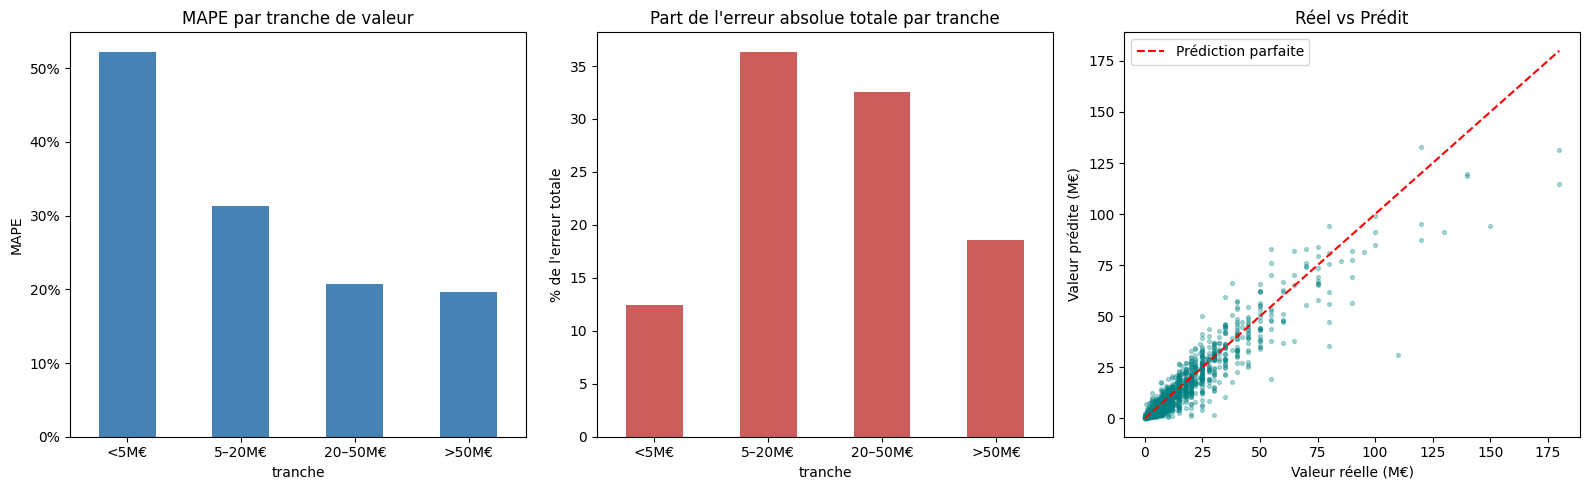

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1 : MAPE par tranche
synthese["MAPE"].plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="none")
axes[0].set_title("MAPE par tranche de valeur")
axes[0].set_ylabel("MAPE")
axes[0].tick_params(axis="x", rotation=0)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))

# Plot 2 : % erreur totale par tranche
synthese["% erreur totale"].plot(kind="bar", ax=axes[1], color="indianred", edgecolor="none")
axes[1].set_title("Part de l'erreur absolue totale par tranche")
axes[1].set_ylabel("% de l'erreur totale")
axes[1].tick_params(axis="x", rotation=0)

# Plot 3 : Valeurs réelles vs prédites
sample = df_erreur.sample(min(2000, len(df_erreur)), random_state=RANDOM_STATE)
axes[2].scatter(sample["y_reel"] / 1e6, sample["y_pred"] / 1e6, alpha=0.3, s=8, color="teal")
lim = max(sample["y_reel"].max(), sample["y_pred"].max()) / 1e6
axes[2].plot([0, lim], [0, lim], "r--", lw=1.5, label="Prédiction parfaite")
axes[2].set_xlabel("Valeur réelle (M€)")
axes[2].set_ylabel("Valeur prédite (M€)")
axes[2].set_title("Réel vs Prédit")
axes[2].legend()

plt.tight_layout()
plt.show()

## Feature importance — CatBoost

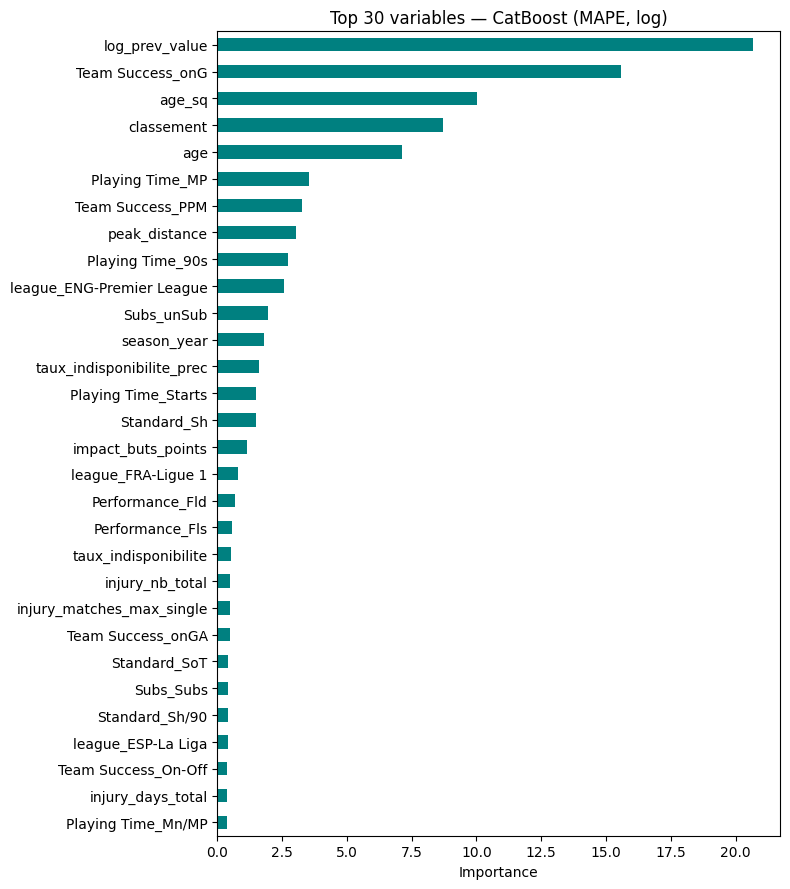


Top 30 :
log_prev_value               20.682772
Team Success_onG             15.574953
age_sq                       10.001441
classement                    8.706288
age                           7.112534
Playing Time_MP               3.543132
Team Success_PPM              3.245247
peak_distance                 3.038851
Playing Time_90s              2.710551
league_ENG-Premier League     2.585368
Subs_unSub                    1.943062
season_year                   1.794032
taux_indisponibilite_prec     1.614530
Playing Time_Starts           1.491210
Standard_Sh                   1.472495
impact_buts_points            1.138475
league_FRA-Ligue 1            0.798816
Performance_Fld               0.672266
Performance_Fls               0.555414
taux_indisponibilite          0.508873
injury_nb_total               0.501860
injury_matches_max_single     0.484576
Team Success_onGA             0.482175
Standard_SoT                  0.425643
Subs_Subs                     0.424932
Standard_Sh/90 

In [16]:
importances = pd.Series(
    cat_final.get_feature_importance(),
    index=X_train.columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 9))
importances.head(30).sort_values().plot(kind="barh", color="teal", ax=ax)
ax.set_title("Top 30 variables — CatBoost (MAPE, log)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

print("\nTop 30 :")
print(importances.head(30).to_string())

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator
import shap



from sklearn.base import BaseEstimator, RegressorMixin


class StackingModel(BaseEstimator, RegressorMixin):

    def __init__(self, models, meta_model):
        self.models = models
        self.meta_model = meta_model

    def fit(self, X, y):
        # Pas besoin de réentraîner les modèles,
        # ils sont déjà entraînés dans ton notebook
        return self

    def predict(self, X):

        # Prédictions des modèles de niveau 1
        X_meta = np.column_stack([
            model.predict(X) for model in self.models
        ])

        # Prédiction du modèle final
        prediction_log = self.meta_model.predict(X_meta)

        # Retour à l'échelle réelle
        return np.expm1(prediction_log)



modele_stack = StackingModel(
    models=[
        modeles_finaux["XGBoost"],
        modeles_finaux["LightGBM"],
        modeles_finaux["CatBoost"]
    ],
    meta_model=meta
)


print("--- PERMUTATION FEATURE IMPORTANCE ---")


result_perm = permutation_importance(
    modele_stack,
    X_val,
    y_val,
    scoring="neg_mean_absolute_percentage_error",
    n_repeats=1,
    random_state=1308,
    n_jobs=-1
)


# Organisation des résultats
sorted_idx = result_perm.importances_mean.argsort()[::-1]


perm_importances = pd.DataFrame(
    {
        "Feature": X_val.columns[sorted_idx],
        "Importance_Mean": -result_perm.importances_mean[sorted_idx],
        "Importance_Std": result_perm.importances_std[sorted_idx]
    }
)


print(perm_importances)

--- PERMUTATION FEATURE IMPORTANCE ---


c:\Users\LouisHarle\OneDrive - Quadratic\Bureau\Stage_VM\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


                           Feature  Importance_Mean  Importance_Std
0                   log_prev_value        -0.885971             0.0
1                 Team Success_onG        -0.432100             0.0
2                              age        -0.219676             0.0
3                       classement        -0.107805             0.0
4        league_ENG-Premier League        -0.064154             0.0
..                             ...              ...             ...
139                         pos_FW         0.000314             0.0
140                 Standard_Sh/90         0.000578             0.0
141             classement_FIFA_10         0.000596             0.0
142  contribution_offensive_equipe         0.000736             0.0
143                   height_in_cm         0.001003             0.0

[144 rows x 3 columns]


In [18]:
# Sélectionner les variables normalisées et créer la clé de jointure sans conflit
df_nor = perm_importances[perm_importances["Feature"].str.endswith("_nor")].copy()
df_nor["Cle_jointure"] = df_nor["Feature"].str.replace("_nor", "")

# Sélectionner les variables brutes correspondantes
df_brutes = perm_importances[perm_importances["Feature"].isin(df_nor["Cle_jointure"])].copy()

# Fusionner les deux DataFrames sur la clé commune
comparatif = pd.merge(
    df_brutes, 
    df_nor, 
    left_on="Feature", 
    right_on="Cle_jointure", 
    suffixes=("_brute", "_normalisee")
)

# Nettoyer et organiser l'affichage
comparatif = comparatif[[
    "Feature_brute", "Importance_Mean_brute", "Importance_Std_brute",
    "Feature_normalisee", "Importance_Mean_normalisee", "Importance_Std_normalisee"
]]

# Optionnel : Calculer la différence d'importance (Brute - Normalisée)
# Si > 0, la brute est plus importante. Si < 0, la normalisée l'emporte.
comparatif["Difference"] = comparatif["Importance_Mean_brute"] - comparatif["Importance_Mean_normalisee"]

print("--- COMPARAISON DES IMPORTANCES (BRUTE VS NORMALISÉE) ---")
print(comparatif.to_string(index=False))

# Définir la règle de décision
def prendre_decision(row):
    # Plus l'importance est élevée, plus la variable est utile.
    # (Note : la permutation importance avec neg_mean_absolute_percentage_error 
    # renvoie des valeurs positives après notre inversion par le signe moins (-) dans ton code d'origine)
    if abs(row["Importance_Mean_normalisee"]) > abs(row["Importance_Mean_brute"]):
        return "Conserver Normalisée"
    else:
        return "Garder Brute (Rejeter _nor)"

# Appliquer la décision sur chaque ligne
comparatif["Decision"] = comparatif.apply(prendre_decision, axis=1)

# Trier par importance pour voir les variables clés en premier
comparatif = comparatif.sort_values(by="Importance_Mean_normalisee", ascending=False)

# Affichage propre
print("--- BILAN ET DÉCISION PAR VARIABLE ---")
print(comparatif[[
    "Feature_brute", "Importance_Mean_brute", 
    "Feature_normalisee", "Importance_Mean_normalisee", 
    "Decision"
]].to_string(index=False))

--- COMPARAISON DES IMPORTANCES (BRUTE VS NORMALISÉE) ---
Empty DataFrame
Columns: [Feature_brute, Importance_Mean_brute, Importance_Std_brute, Feature_normalisee, Importance_Mean_normalisee, Importance_Std_normalisee, Difference]
Index: []
--- BILAN ET DÉCISION PAR VARIABLE ---
Empty DataFrame
Columns: [Feature_brute, Importance_Mean_brute, Feature_normalisee, Importance_Mean_normalisee, Decision]
Index: []


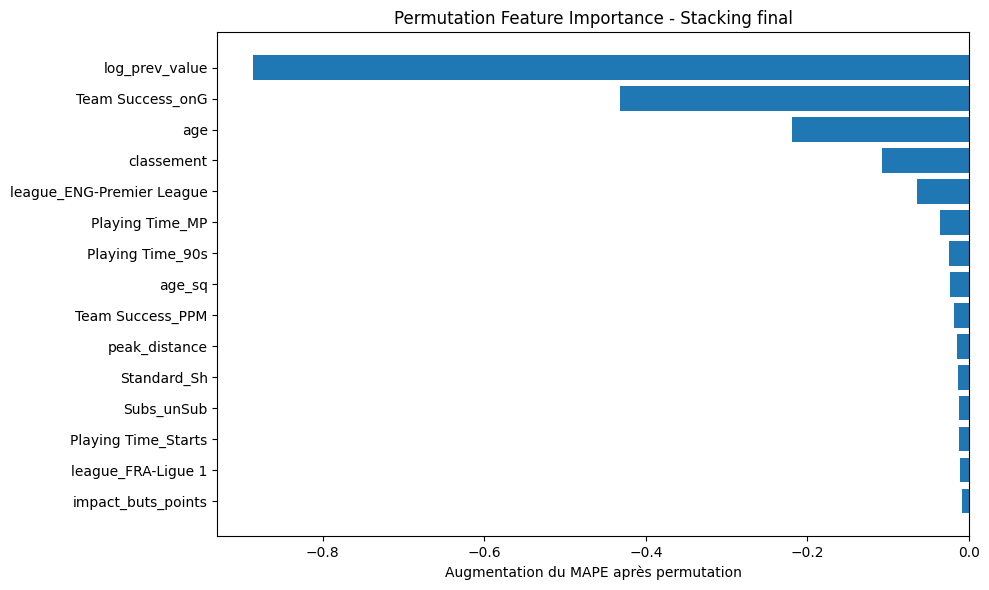

Background dataset has 2431 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=2431 when initializing the masker.



--- SHAP DU STACKING FINAL ---


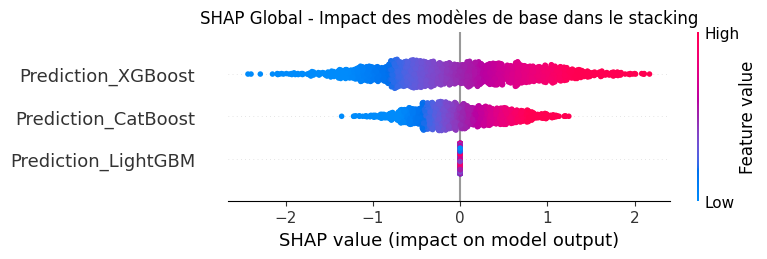

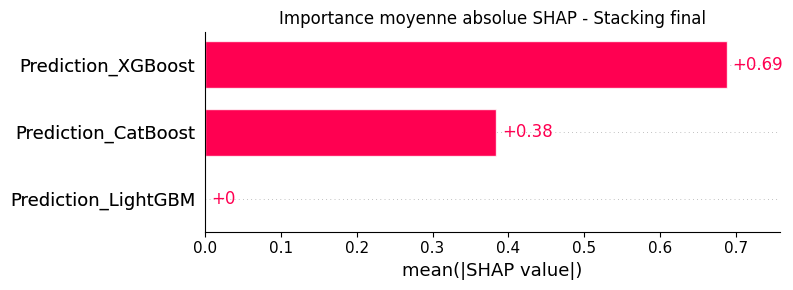


Explication locale de la première prédiction du jeu de validation


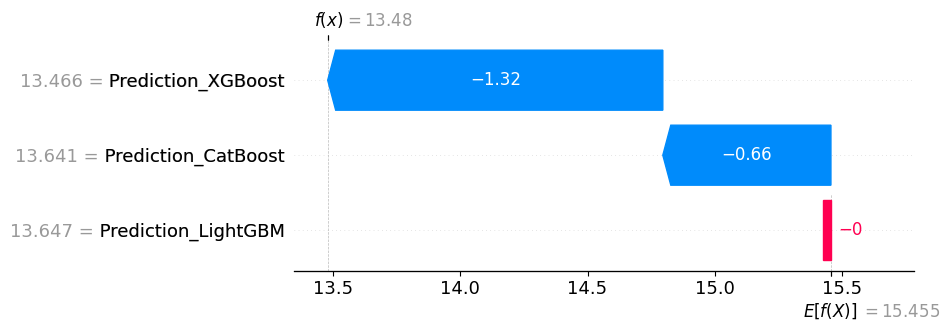

In [19]:
# Graphique
plt.figure(figsize=(10,6))

plt.barh(
    perm_importances["Feature"].head(15)[::-1],
    perm_importances["Importance_Mean"].head(15)[::-1],
    xerr=perm_importances["Importance_Std"].head(15)[::-1]
)

plt.xlabel("Augmentation du MAPE après permutation")
plt.title("Permutation Feature Importance - Stacking final")
plt.tight_layout()
plt.show()



print("\n--- SHAP DU STACKING FINAL ---")


# Le méta-modèle travaille sur les prédictions des modèles de base
X_meta_val = np.column_stack(
    [
        modeles_finaux["XGBoost"].predict(X_val),
        modeles_finaux["LightGBM"].predict(X_val),
        modeles_finaux["CatBoost"].predict(X_val)
    ]
)


# Noms des variables du stacking
X_meta_val = pd.DataFrame(
    X_meta_val,
    columns=[
        "Prediction_XGBoost",
        "Prediction_LightGBM",
        "Prediction_CatBoost"
    ]
)


# Explainer adapté à LinearRegression
explainer = shap.LinearExplainer(
    meta,
    X_meta_val
)


shap_values = explainer(X_meta_val)



plt.figure(figsize=(10,6))

shap.plots.beeswarm(
    shap_values,
    max_display=10,
    show=False
)

plt.title(
    "SHAP Global - Impact des modèles de base dans le stacking"
)

plt.tight_layout()
plt.show()





plt.figure(figsize=(10,6))

shap.plots.bar(
    shap_values,
    max_display=10,
    show=False
)

plt.title(
    "Importance moyenne absolue SHAP - Stacking final"
)

plt.tight_layout()
plt.show()





print(
    "\nExplication locale de la première prédiction du jeu de validation"
)


shap.plots.waterfall(
    shap_values[0],
    max_display=10
)

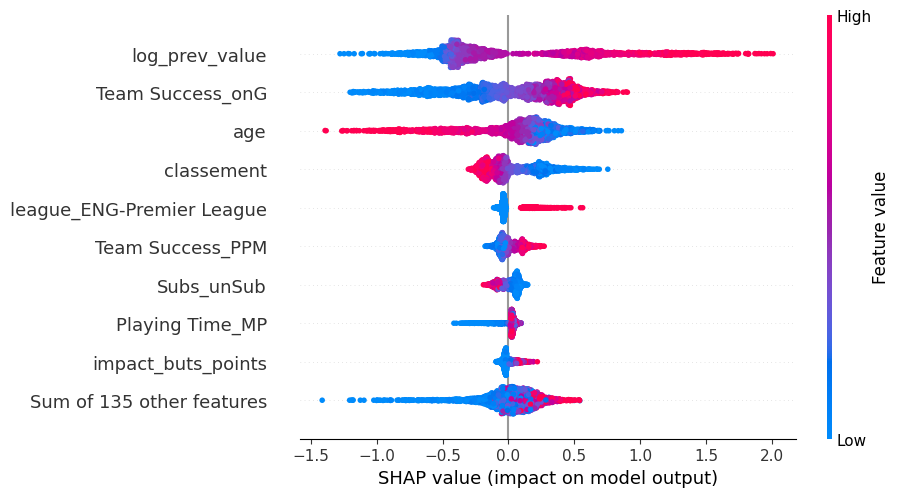

In [20]:
# Exemple sur XGBoost uniquement
explainer_xgb = shap.TreeExplainer(modeles_finaux["XGBoost"])
shap_values_xgb = explainer_xgb(X_val)

shap.plots.beeswarm(shap_values_xgb)

refaire le même avec barres et sous-cas (exemple donné par Thibault)

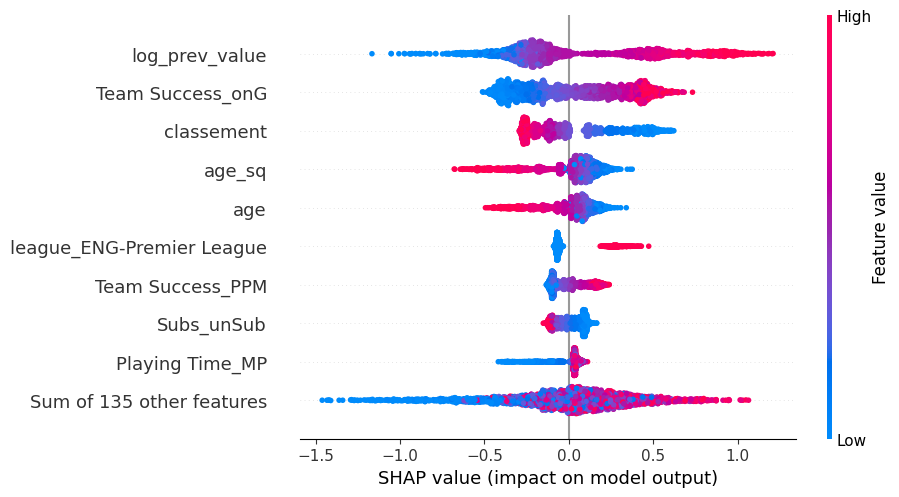

In [21]:
# Exemple sur CatBoost uniquement
explainer_cb = shap.TreeExplainer(modeles_finaux["CatBoost"])
shap_values_cb = explainer_cb(X_val)

shap.plots.beeswarm(shap_values_cb)

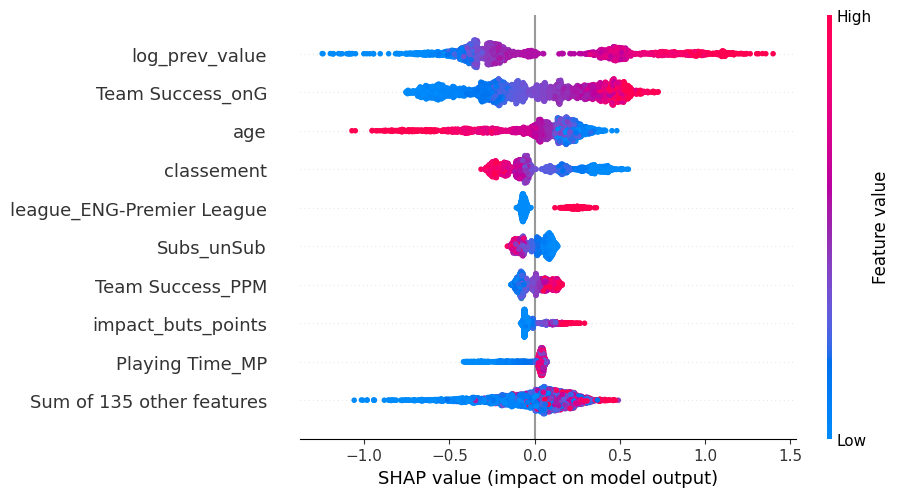

In [22]:
# Exemple sur LightGBM uniquement
explainer_lgb = shap.TreeExplainer(modeles_finaux["LightGBM"])
shap_values_lgb = explainer_lgb(X_val)

shap.plots.beeswarm(shap_values_lgb)

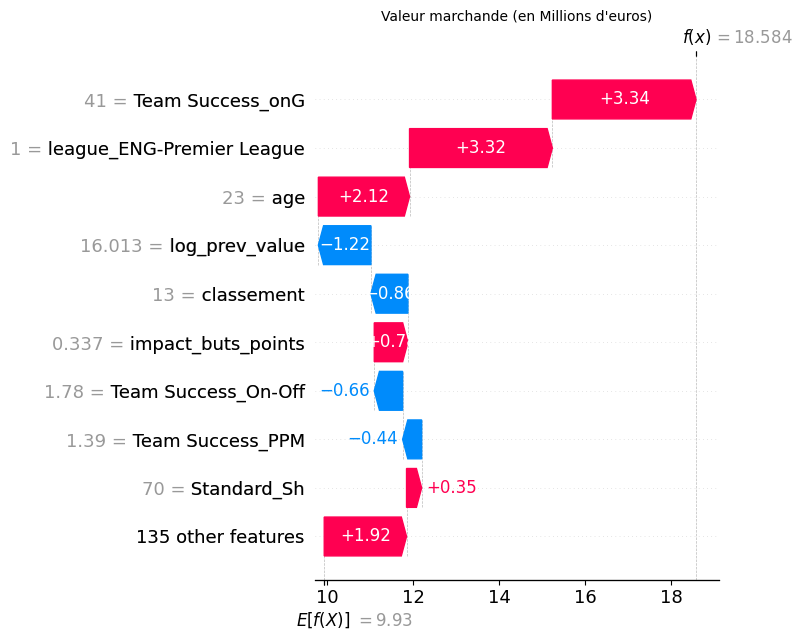

In [23]:
import numpy as np
import shap
import matplotlib.pyplot as plt

# Définition du modèle et des données
model_xgb = modeles_finaux["XGBoost"]
indice_joueur = 200

# Fonction wrapper qui prédit directement en Millions d'euros
def predict_m_euro(X):
    # Passe du log(Prix) à l'Euro, puis en Millions
    return np.exp(model_xgb.predict(X)) / 1_000_000

# Création de l'explicateur SHAP sur la vraie valeur (€)
# On utilise un échantillon de fond (ex: 100 lignes) pour calculer les références
background_data = shap.sample(X_val, 100)
explainer_m_euro = shap.Explainer(predict_m_euro, background_data)

# Calcul des valeurs SHAP pour le joueur choisi
shap_values_m_euro = explainer_m_euro(X_val.iloc[[indice_joueur]])

# Affichage du waterfall
plt.figure(figsize=(9, 6))
shap.plots.waterfall(shap_values_m_euro[0], show=False)

plt.xlabel("Valeur marchande (en Millions d'euros)")
plt.tight_layout()
plt.show()

In [24]:
# Initialiser javascript pour l'affichage dans le notebook
shap.initjs()

# Afficher le force plot pour le même joueur
shap.plots.force(explainer_xgb.expected_value, shap_values_xgb.values[indice_joueur], X_val.iloc[indice_joueur])

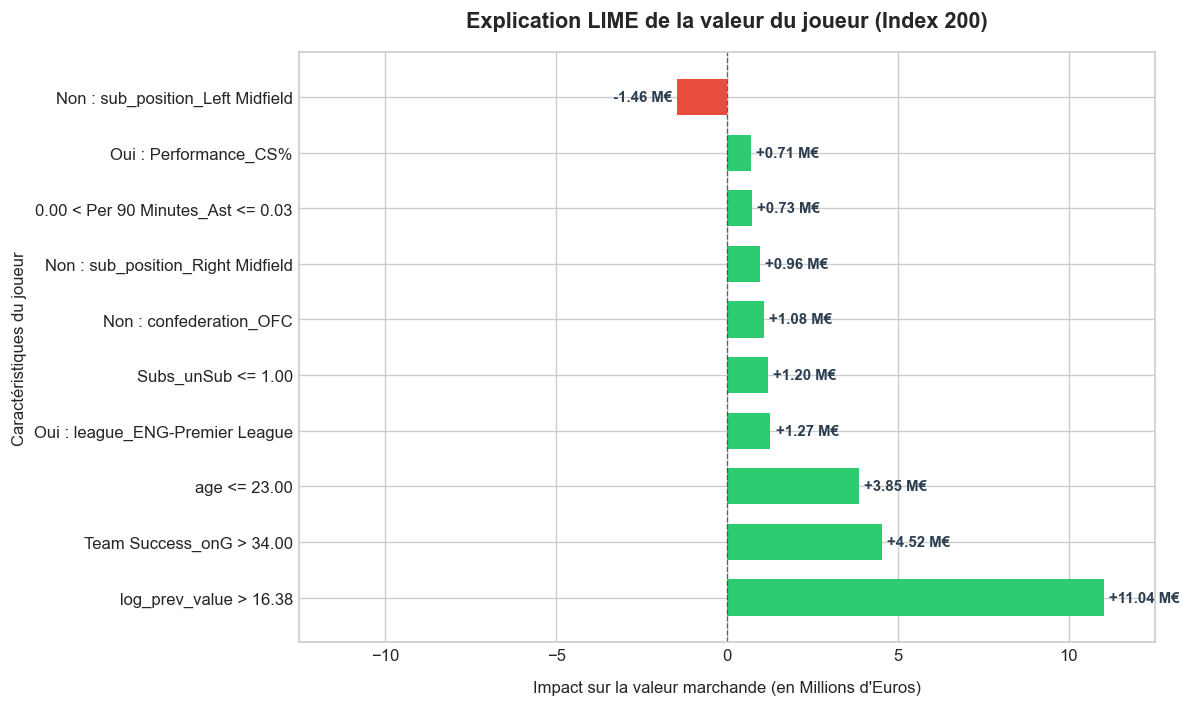

In [25]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
import lime
import lime.lime_tabular


indice_joueur = 200


model = modeles_finaux["XGBoost"]

# Imputation des NaN pour LIME
imputer = SimpleImputer(strategy='median')
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test_imputed = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

# Fonction de prédiction en Millions d'Euros
def predict_m_euro(X):
    if isinstance(X, np.ndarray):
        X = pd.DataFrame(X, columns=X_train.columns)
    log_preds = model.predict(X)
    return np.exp(log_preds) / 1_000_000

# Création de l'explicateur LIME
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train_imputed),
    feature_names=list(X_train.columns),
    class_names=['Valeur_M_Euro'],
    mode='regression',
    random_state=42
)

# Extraction des données du joueur choisi
joueur_data = X_test_imputed.iloc[indice_joueur].values

# Calcul de l'explication LIME
exp = explainer.explain_instance(
    data_row=joueur_data,
    predict_fn=predict_m_euro,
    num_features=10
)



# Extraction des données
list_exp = exp.as_list()
df_lime = pd.DataFrame(list_exp, columns=['Feature_Condition', 'Impact'])
df_lime = df_lime.sort_values(by='Impact', ascending=False)

# Nettoyage des étiquettes
def clean_feature_label(condition):
    if "<= 0.00" in condition:
        feat = condition.replace(" <= 0.00", "")
        return f"Non : {feat}"
    elif "> 0.00" in condition:
        feat = condition.replace(" > 0.00", "")
        return f"Oui : {feat}"
    return condition

df_lime['Pretty_Label'] = df_lime['Feature_Condition'].apply(clean_feature_label)
df_lime['Color'] = df_lime['Impact'].apply(lambda x: '#2ecc71' if x > 0 else '#e74c3c')

# Création de la figure
plt.figure(figsize=(10, 6), dpi=120)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

bars = plt.barh(
    y=df_lime['Pretty_Label'], 
    width=df_lime['Impact'], 
    color=df_lime['Color'],
    edgecolor='none',
    height=0.65
)

plt.axvline(x=0, color='#333333', linestyle='--', linewidth=0.8, alpha=0.7)

# Textes au bout des barres
for bar in bars:
    width = bar.get_width()
    x_pos = width + (0.15 if width > 0 else -0.15)
    ha = 'left' if width > 0 else 'right'
    
    plt.text(
        x_pos, 
        bar.get_y() + bar.get_height()/2, 
        f"{width:+.2f} M€", 
        va='center', 
        ha=ha, 
        fontsize=9, 
        fontweight='bold',
        color='#2c3e50'
    )

# Titre et axes
plt.title(f"Explication LIME de la valeur du joueur (Index {indice_joueur})", fontsize=13, pad=15, fontweight='bold')
plt.xlabel("Impact sur la valeur marchande (en Millions d'Euros)", fontsize=10, labelpad=10)
plt.ylabel("Caractéristiques du joueur", fontsize=10)

x_max = max(abs(df_lime['Impact'].min()), abs(df_lime['Impact'].max())) + 1.5
plt.xlim(-x_max, x_max)

plt.tight_layout()
plt.show()

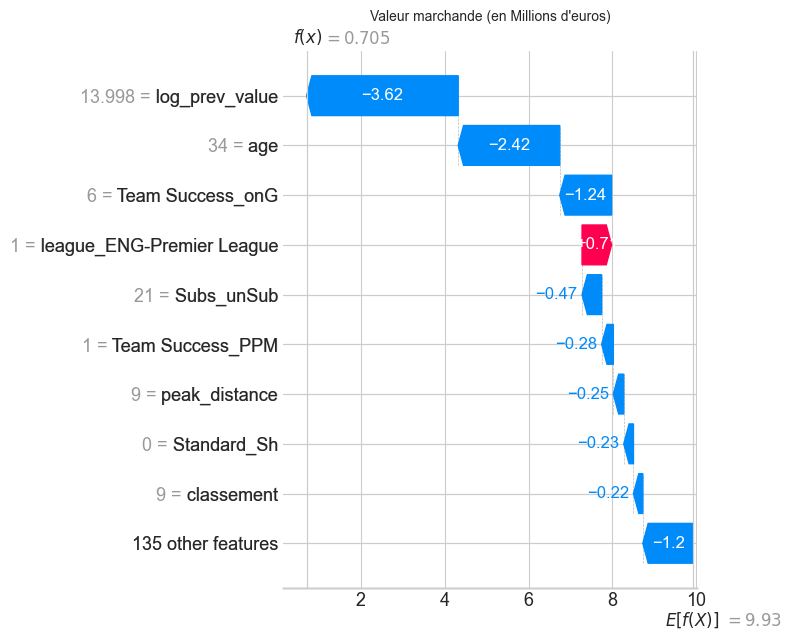

In [26]:
import numpy as np
import shap
import matplotlib.pyplot as plt

# Définition du modèle et des données
model_xgb = modeles_finaux["XGBoost"]
indice_joueur = 0

# Fonction wrapper qui prédit directement en Millions d'euros
def predict_m_euro(X):
    # Passe du log(Prix) à l'Euro, puis en Millions
    return np.exp(model_xgb.predict(X)) / 1_000_000

# Création de l'explicateur SHAP sur la vraie valeur (€)
# On utilise un échantillon de fond (ex: 100 lignes) pour calculer les références
background_data = shap.sample(X_val, 100)
explainer_m_euro = shap.Explainer(predict_m_euro, background_data)

# Calcul des valeurs SHAP pour le joueur choisi
shap_values_m_euro = explainer_m_euro(X_val.iloc[[indice_joueur]])

# Affichage du waterfall
plt.figure(figsize=(9, 6))
shap.plots.waterfall(shap_values_m_euro[0], show=False)

plt.xlabel("Valeur marchande (en Millions d'euros)")
plt.tight_layout()
plt.show()

In [27]:
# Initialiser javascript pour l'affichage dans le notebook
shap.initjs()

# Afficher le force plot pour le même joueur
shap.plots.force(explainer_xgb.expected_value, shap_values_xgb.values[indice_joueur], X_val.iloc[indice_joueur])

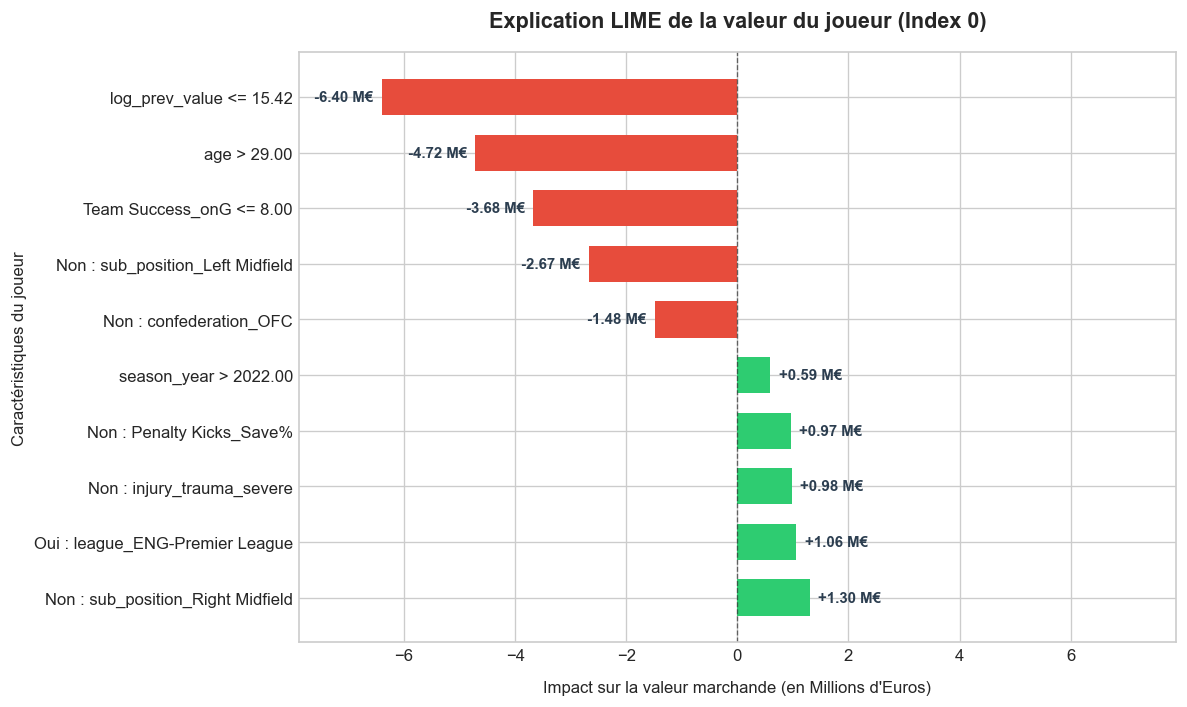

In [28]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
import lime
import lime.lime_tabular


indice_joueur = 0


model = modeles_finaux["XGBoost"]

# Imputation des NaN pour LIME
imputer = SimpleImputer(strategy='median')
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test_imputed = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

# Fonction de prédiction en Millions d'Euros
def predict_m_euro(X):
    if isinstance(X, np.ndarray):
        X = pd.DataFrame(X, columns=X_train.columns)
    log_preds = model.predict(X)
    return np.exp(log_preds) / 1_000_000

# Création de l'explicateur LIME
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train_imputed),
    feature_names=list(X_train.columns),
    class_names=['Valeur_M_Euro'],
    mode='regression',
    random_state=42
)

# Extraction des données du joueur choisi
joueur_data = X_test_imputed.iloc[indice_joueur].values

# Calcul de l'explication LIME
exp = explainer.explain_instance(
    data_row=joueur_data,
    predict_fn=predict_m_euro,
    num_features=10
)



# Extraction des données
list_exp = exp.as_list()
df_lime = pd.DataFrame(list_exp, columns=['Feature_Condition', 'Impact'])
df_lime = df_lime.sort_values(by='Impact', ascending=False)

# Nettoyage des étiquettes
def clean_feature_label(condition):
    if "<= 0.00" in condition:
        feat = condition.replace(" <= 0.00", "")
        return f"Non : {feat}"
    elif "> 0.00" in condition:
        feat = condition.replace(" > 0.00", "")
        return f"Oui : {feat}"
    return condition

df_lime['Pretty_Label'] = df_lime['Feature_Condition'].apply(clean_feature_label)
df_lime['Color'] = df_lime['Impact'].apply(lambda x: '#2ecc71' if x > 0 else '#e74c3c')

# Création de la figure
plt.figure(figsize=(10, 6), dpi=120)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

bars = plt.barh(
    y=df_lime['Pretty_Label'], 
    width=df_lime['Impact'], 
    color=df_lime['Color'],
    edgecolor='none',
    height=0.65
)

plt.axvline(x=0, color='#333333', linestyle='--', linewidth=0.8, alpha=0.7)

# Textes au bout des barres
for bar in bars:
    width = bar.get_width()
    x_pos = width + (0.15 if width > 0 else -0.15)
    ha = 'left' if width > 0 else 'right'
    
    plt.text(
        x_pos, 
        bar.get_y() + bar.get_height()/2, 
        f"{width:+.2f} M€", 
        va='center', 
        ha=ha, 
        fontsize=9, 
        fontweight='bold',
        color='#2c3e50'
    )

# Titre et axes
plt.title(f"Explication LIME de la valeur du joueur (Index {indice_joueur})", fontsize=13, pad=15, fontweight='bold')
plt.xlabel("Impact sur la valeur marchande (en Millions d'Euros)", fontsize=10, labelpad=10)
plt.ylabel("Caractéristiques du joueur", fontsize=10)

x_max = max(abs(df_lime['Impact'].min()), abs(df_lime['Impact'].max())) + 1.5
plt.xlim(-x_max, x_max)

plt.tight_layout()
plt.show()